# Preprocessing - Obianuju Nonyerem Anuma

DDPM Samples:


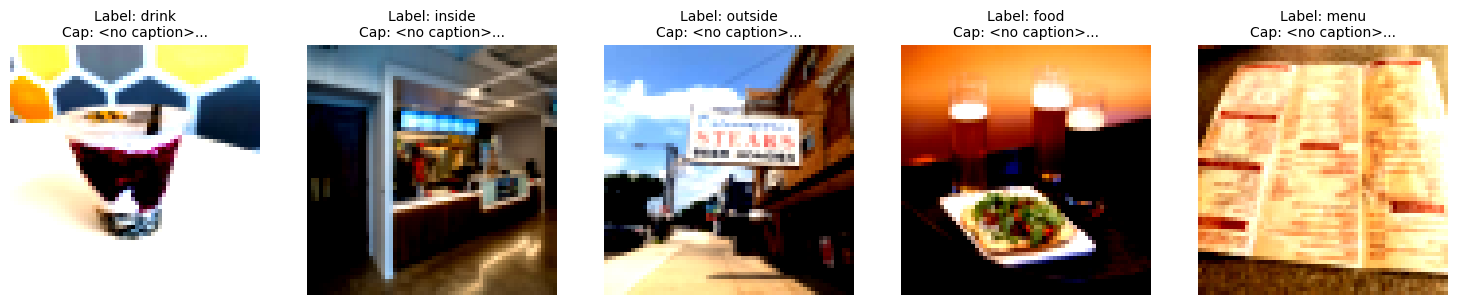

In [9]:
# -------------------------------
# Imports and Config
# -------------------------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from transformers import CLIPTokenizer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# Load Data
# -------------------------------
metadata_path = "C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos.json"
df = pd.read_json(metadata_path, lines=True)

# -------------------------------
# Data Split
# -------------------------------
def split_json_df(df, test_size=0.2, random_state=42):
    """Split DataFrame into stratified train and test sets"""
    return train_test_split(df, test_size=test_size, stratify=df["label"], random_state=random_state)

train_df, test_df = split_json_df(df)

# -------------------------------
# Image Transforms
# -------------------------------
def get_transforms(augment=False):
    """Return torchvision transforms with optional augmentation"""
    transform_list = [transforms.Resize((64, 64))]
    if augment:
        transform_list.append(transforms.RandomHorizontalFlip())
    transform_list += [
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
    ]
    return transforms.Compose(transform_list)

# -------------------------------
# Dataset Classes
# -------------------------------
class YelpJSONDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, menu_transform=None):
        """
        Dataset for Yelp image metadata

        Args:
            dataframe (DataFrame): Image metadata
            image_dir (str): Folder path to image files
            transform (callable): Default image transform
            menu_transform (callable): Transform applied only to 'menu' images
        """
        self.data = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.menu_transform = menu_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data.iloc[idx]
        img_path = os.path.join(self.image_dir, f"{item['photo_id']}.jpg")
        image = Image.open(img_path).convert("RGB")
        label = item['label']

        # Apply menu-specific transform
        if label == 'menu' and self.menu_transform:
            image = self.menu_transform(image)
        elif self.transform:
            image = self.transform(image)

        return image, label, ""

# -------------------------------
# Preprocessing Pipelines
# -------------------------------
def preprocess_ddpm(train_df, test_df, image_dir):
    base_transform = get_transforms(augment=False)
    menu_transform = get_transforms(augment=True)
    test_transform = get_transforms(augment=False)
    return (
        YelpJSONDataset(train_df, image_dir, transform=base_transform, menu_transform=menu_transform),
        YelpJSONDataset(test_df, image_dir, transform=test_transform)
    )

def preprocess_ddim(train_df, test_df, image_dir):
    return preprocess_ddpm(train_df, test_df, image_dir)

def preprocess_latent_diffusion(train_df, test_df, image_dir):
    return preprocess_ddpm(train_df, test_df, image_dir)

class YelpTextToImageDataset(YelpJSONDataset):
    def __init__(self, dataframe, image_dir, transform=None, menu_transform=None, tokenizer=None):
        """
        Extension of YelpJSONDataset for text-to-image models

        Args:
            tokenizer: CLIPTokenizer for encoding captions
        """
        super().__init__(dataframe, image_dir, transform, menu_transform)
        self.tokenizer = tokenizer

    def __getitem__(self, idx):
        image, label, _ = super().__getitem__(idx)
        caption = label  # Using label as caption for now
        if self.tokenizer:
            caption = self.tokenizer(caption, padding="max_length", truncation=True, return_tensors="pt")
        return image, label, caption

def preprocess_text_to_image(train_df, test_df, image_dir, tokenizer):
    base_transform = get_transforms(augment=False)
    menu_transform = get_transforms(augment=True)
    test_transform = get_transforms(augment=False)
    return (
        YelpTextToImageDataset(train_df, image_dir, transform=base_transform, menu_transform=menu_transform, tokenizer=tokenizer),
        YelpTextToImageDataset(test_df, image_dir, transform=test_transform, tokenizer=tokenizer)
    )

# -------------------------------
# Visualization Utility
# -------------------------------
def show_sample_images(dataset, num_samples=5, show_caption=True):
    """
    Plots sample images from the dataset with their labels and captions.

    Args:
        dataset (Dataset): Dataset object
        num_samples (int): Number of images to preview
        show_caption (bool): Show caption text under each image
    """
    plt.figure(figsize=(15, 3))
    for i in range(num_samples):
        image, label, caption = dataset[i]
        image = image.numpy().transpose(1, 2, 0)
        image = image + 0.5
        image = np.clip(image, 0, 1)

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(image)
        plt.axis('off')

        if isinstance(caption, dict):
            try:
                input_ids = caption["input_ids"][0]
                caption_text = tokenizer.decode(input_ids, skip_special_tokens=True)
            except Exception:
                caption_text = "<tokenized>"
        else:
            caption_text = caption if caption else "<no caption>"

        title = f"Label: {label}"
        if show_caption:
            title += f"\nCap: {caption_text[:30]}..."
        plt.title(title, fontsize=10)

    plt.tight_layout()
    plt.show()

# -------------------------------
# Run Preprocessors
# -------------------------------
image_dir = "C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\Yelp-Photos\\Yelp Photos\\yelp_photos\\photos"
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

train_ddpm, test_ddpm = preprocess_ddpm(train_df, test_df, image_dir)
#train_ddim, test_ddim = preprocess_ddim(train_df, test_df, image_dir)
#train_ldm, test_ldm = preprocess_latent_diffusion(train_df, test_df, image_dir)
#train_glide, test_glide = preprocess_text_to_image(train_df, test_df, image_dir, tokenizer)

# -------------------------------
# Preview Samples
# -------------------------------
print("DDPM Samples:")
show_sample_images(train_ddpm)

#print("DDIM Samples:")
#show_sample_images(train_ddim)

#print("Latent Diffusion Samples:")
#show_sample_images(train_ldm)

#print("Text-to-Image Diffusion Samples:")
#show_sample_images(train_glide, show_caption=True)

# -------------------------------
# Save Datasets
# -------------------------------

# Exporting the datasets for later use:
# Option 1: Saving as Pytorch Objects
torch.save(train_ddpm, "train_ddpm.pt")
torch.save(test_ddpm, "test_ddpm.pt")

#torch.save(train_ddim, "train_ddim.pt")
#torch.save(test_ddim, "test_ddim.pt")

#torch.save(train_ldm, "train_ldm.pt")
#torch.save(test_ldm, "test_ldm.pt")

#torch.save(train_glide, "train_glide.pt")
#torch.save(test_glide, "test_glide.pt")

# Option 2: Saving the test and train csv files (underlying data)
train_df.to_csv("train_metadata.csv", index=False)
test_df.to_csv("test_metadata.csv", index=False)

In [ ]:
# Note to colleagues:
# If using PyTorch, get the dataset objects directly using torch.load("train_ddpm.pt") for example.
# If using the underlying data,run the preprocessing step for your model. This provides more flexibility.

In [11]:
pip install torch pandas transformers diffusers tqdm --quiet

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install diffusers --quiet

Note: you may need to restart the kernel to use updated packages.


In [13]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from diffusers import DDPMScheduler, UNet2DModel  # Correct import  # Assuming we're using HuggingFace's diffusers
from tqdm import tqdm
import numpy as np

# 1. Data Loading and Preparation
class YelpTextDataset(Dataset):
    def __init__(self, data_path, tokenizer_name="bert-base-uncased", max_length=128):
        """
        Load the serialized data and prepare for training
        """
        # Load the serialized data
        data = torch.load(data_path)
        self.texts = data['data'].tolist()  # Assuming the text is in a 'data' column
        
        # Initialize tokenizer
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        tokens = self.tokenizer(
            text,
            padding='max_length',
            max_length=self.max_length,
            truncation=True,
            return_tensors='pt'
        )
        return tokens['input_ids'].squeeze()

# 2. Model Definition
def create_model(vocab_size=30522, embedding_dim=128):
    """Create a UNet model suitable for text diffusion"""
    model = UNet2DModel(
        sample_size=128,  # Should match max_length
        in_channels=embedding_dim,
        out_channels=embedding_dim,
        layers_per_block=2,
        block_out_channels=(128, 256, 512),
        down_block_types=(
            "DownBlock2D",
            "AttnDownBlock2D",
            "AttnDownBlock2D",
        ),
        up_block_types=(
            "AttnUpBlock2D",
            "AttnUpBlock2D",
            "UpBlock2D",
        ),
    )
    return model

# 3. Training Loop
def train(model, dataloader, optimizer, scheduler, device, num_epochs=5):
    model.train()
    model.to(device)
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
        
        for batch in progress_bar:
            # Move batch to device
            batch = batch.to(device)
            
            # Sample noise to add to the inputs
            noise = torch.randn_like(batch)
            
            # Sample a random timestep for each item in the batch
            timesteps = torch.randint(
                0, scheduler.num_train_timesteps, (batch.size(0),), device=device
            ).long()
            
            # Add noise to the clean inputs according to the noise magnitude at each timestep
            noisy_inputs = scheduler.add_noise(batch, noise, timesteps)
            
            # Predict the noise residual
            noise_pred = model(noisy_inputs, timesteps).sample
            
            # Calculate loss
            loss = torch.nn.functional.mse_loss(noise_pred, noise)
            
            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            progress_bar.set_postfix({"loss": loss.item()})
        
        avg_loss = epoch_loss / len(dataloader)
        print(f"Epoch {epoch+1} average loss: {avg_loss:.4f}")

# 4. Main Training Pipeline
def main():
    # Configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    batch_size = 32
    learning_rate = 1e-4
    num_epochs = 20
    
    # Load datasets
    train_dataset = YelpTextDataset("C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\train_ddpm.pt")
    # Assuming you have a test file named 'test_ddpm.pt'
    test_dataset = YelpTextDataset("C:\\PG AI and DS\\Semester 3\\Computer Vision AISC2008\\test_ddpm.pt")  
    
    # Create dataloaders
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size)
    
    # Initialize model and components
    model = create_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
    
    # Initialize scheduler
    noise_scheduler = DDPMScheduler(
        num_train_timesteps=1000,
        beta_schedule="linear",
        beta_start=0.0001,
        beta_end=0.02,
        clip_sample=True,
    )
    
    # Train the model
    train(model, train_dataloader, optimizer, noise_scheduler, device, num_epochs)
    
    # Save the trained model
    torch.save(model.state_dict(), "text_diffusion_model.pt")

if __name__ == "__main__":
    main()

C:\Users\Admin\AppData\Local\Temp\ipykernel_18468\1812657179.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(data_path)


AttributeError: Can't get attribute 'YelpJSONDataset' on <module '__main__'>

In [15]:
pip install ddpm 

Note: you may need to restart the kernel to use updated packages.


ERROR: Ignored the following versions that require a different python version: 1.0.0 Requires-Python <3.10,>=3.7
ERROR: Could not find a version that satisfies the requirement ddpm (from versions: none)
ERROR: No matching distribution found for ddpm


In [1]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset
from PIL import Image
import os
import random

# Define dataset class
class YelpDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_paths = [os.path.join(root_dir, f) for f in os.listdir(root_dir) if f.endswith(('.jpg', '.png'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

# Define transformations
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Create dataset and dataloader
dataset = YelpDataset(root_dir='C:\\Users\\Admin\\Downloads\\train 1\\Train1\\original_photos\\', transform=transform)
#dataloader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)
# Randomly select 5000 indices
indices = random.sample(range(len(dataset)), 10000)

# Create a downsampled subset
downsampled_dataset = Subset(dataset, indices)

dataloader = DataLoader(downsampled_dataset, batch_size=64, shuffle=True, num_workers=0)  # num_workers=0 for Windows

# Verify dataset
print(f"{len(dataset)} images loaded")
print(f"{len(dataloader)} sample")
if len(dataset) == 0:
    raise ValueError("No images found! Check your dataset path")

21510 images loaded
157 sample


In [2]:
num_timesteps = 1000
beta_start = 0.0001
beta_end = 0.02

# Linear variance schedule
betas = torch.linspace(beta_start, beta_end, num_timesteps)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

In [3]:
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.norm1 = nn.BatchNorm2d(in_channels)
        self.norm2 = nn.BatchNorm2d(out_channels)
        self.act = nn.SiLU()
        self.residual_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        residual = x
        x = self.norm1(x)
        x = self.act(x)
        x = self.conv1(x)
        x = self.norm2(x)
        x = self.act(x)
        x = self.conv2(x)
        return x + self.residual_conv(residual)
  

class AttentionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(32, channels)
        self.q = nn.Conv2d(channels, channels, kernel_size=1)
        self.k = nn.Conv2d(channels, channels, kernel_size=1)
        self.v = nn.Conv2d(channels, channels, kernel_size=1)
        self.out_conv = nn.Conv2d(channels, channels, kernel_size=1)

    def forward(self, x):
        B, C, H, W = x.shape
        residual = x
        x = self.norm(x)
        q, k, v = self.q(x), self.k(x), self.v(x)
        q = q.reshape(B, C, -1).permute(0, 2, 1)
        k = k.reshape(B, C, -1)
        v = v.reshape(B, C, -1).permute(0, 2, 1)
        attn = torch.softmax(q @ k / (C**0.5), dim=-1)
        x = (attn @ v).permute(0, 2, 1).reshape(B, C, H, W)
        x = self.out_conv(x)
        return x + residual

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Downsample blocks
        self.down1 = nn.ModuleList([
            ResidualBlock(3, 64),
            ResidualBlock(64, 64)
        ])
        self.down2 = nn.ModuleList([
            ResidualBlock(64, 128),
            ResidualBlock(128, 128)
        ])
        self.down3 = nn.ModuleList([
            ResidualBlock(128, 256),
            ResidualBlock(256, 256)
        ])
        self.attn = AttentionBlock(256)
        
        # Upsample blocks
        self.up3 = nn.ModuleList([
            ResidualBlock(256 + 128, 256),
            ResidualBlock(256, 128)
        ])
        self.up2 = nn.ModuleList([
            ResidualBlock(128 + 64, 128),
            ResidualBlock(128, 64)
        ])
        self.up1 = nn.ModuleList([
            ResidualBlock(64, 64),
            nn.Conv2d(64, 3, kernel_size=3, padding=1)
        ])
        
        self.pool = nn.AvgPool2d(2)
        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)  # Changed to bilinear

    def forward(self, x, t):
        # Downsample path
        d1 = self.down1[0](x)
        d1 = self.down1[1](d1)
        d2 = self.pool(d1)
        d2 = self.down2[0](d2)
        d2 = self.down2[1](d2)
        d3 = self.pool(d2)
        d3 = self.down3[0](d3)
        d3 = self.down3[1](d3)
        d3 = self.attn(d3)
        
        # Upsample path
        u3 = F.interpolate(d3, scale_factor=2, mode='bilinear', align_corners=True)
        u3 = torch.cat([u3, d2], dim=1)
        u3 = self.up3[0](u3)
        u3 = self.up3[1](u3)
        
        u2 = F.interpolate(u3, scale_factor=2, mode='bilinear', align_corners=True)
        u2 = torch.cat([u2, d1], dim=1)
        u2 = self.up2[0](u2)
        u2 = self.up2[1](u2)
        
        u1 = self.up1[0](u2)
        u1 = self.up1[1](u1)
        
        return u1

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
print(device)


cuda


In [9]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create diffusion schedule on device
num_timesteps = 1000
beta_start = 0.0001
beta_end = 0.02
betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

# Initialize model and optimizer
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

# Training loop
for epoch in range(25):
    print(f"\nEpoch {epoch + 1}")
    for batch in dataloader:
        optimizer.zero_grad()
        batch = batch.to(device)
        
        # Create tensors directly on device
        t = torch.randint(0, num_timesteps, (batch.size(0),), device=device)
        noise = torch.randn_like(batch)
        
        # Compute noisy image (all tensors on same device)
        alpha_t = alphas_cumprod[t].view(-1, 1, 1, 1)
        noisy_img = torch.sqrt(alpha_t) * batch + torch.sqrt(1 - alpha_t) * noise
        
        # Predict noise and compute loss
        pred_noise = model(noisy_img, t)
        loss = F.mse_loss(pred_noise, noise)
        
        loss.backward()
        optimizer.step()
print(loss)        


Epoch 1

Epoch 2

Epoch 3

Epoch 4

Epoch 5

Epoch 6

Epoch 7

Epoch 8

Epoch 9

Epoch 10

Epoch 11

Epoch 12

Epoch 13

Epoch 14

Epoch 15

Epoch 16

Epoch 17

Epoch 18

Epoch 19

Epoch 20

Epoch 21

Epoch 22

Epoch 23

Epoch 24

Epoch 25
tensor(0.0502, device='cuda:0', grad_fn=<MseLossBackward0>)


In [11]:
from pathlib import Path

path = Path(r'C:\Users\Admin\Downloads\train 1\Train1\original_photos')

print(f"Exists: {path.exists()}")
print(f"Is dir: {path.is_dir()}")
print(f"Readable: {os.access(path, os.R_OK)}")
print(f"Writable: {os.access(path, os.W_OK)}")
print(f"Executable: {os.access(path, os.X_OK)}")

Exists: True
Is dir: True
Readable: True
Writable: True
Executable: True


In [19]:
# Save model after training
torch.save(model.state_dict(), "ddpm_model.pth")
print("Model saved as ddpm_model.pth")


Model saved as ddpm_model.pth


In [43]:
import torch
import numpy as np
from torchvision.utils import make_grid, save_image
from torchmetrics.image.fid import FrechetInceptionDistance
from tqdm import tqdm

# Precompute diffusion schedule parameters for sampling
def get_diffusion_params(device):
    num_timesteps = 1000
    beta_start = 0.0001
    beta_end = 0.02
    
    betas = torch.linspace(beta_start, beta_end, num_timesteps, device=device)
    alphas = 1. - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    alphas_cumprod_prev = torch.cat([torch.ones(1, device=device), alphas_cumprod[:-1]])
    
    # Precompute values for sampling
    sqrt_recip_alphas = torch.sqrt(1.0 / alphas)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - alphas_cumprod)
    coeff = betas / sqrt_one_minus_alphas_cumprod
    
    # For posterior variance calculation
    posterior_variance = betas * (1. - alphas_cumprod_prev) / (1. - alphas_cumprod)
    
    return {
        "betas": betas,
        "sqrt_recip_alphas": sqrt_recip_alphas,
        "coeff": coeff,
        "posterior_variance": posterior_variance
    }

# Sampling function
@torch.no_grad()
def sample(model, image_size, batch_size=16, device="cuda", timesteps=1000):
    """
    Generate images using the DDPM sampling process
    
    Args:
        model: Trained UNet model
        image_size: Size of generated images (square)
        batch_size: Number of images to generate
        device: Device to use
        timesteps: Number of diffusion timesteps
    
    Returns:
        Generated images in range [-1, 1]
    """
    # Set model to evaluation mode
    model.eval()
    
    # Get precomputed diffusion parameters
    params = get_diffusion_params(device)
    betas = params["betas"]
    sqrt_recip_alphas = params["sqrt_recip_alphas"]
    coeff = params["coeff"]
    posterior_variance = params["posterior_variance"]
    
    # Start from random noise
    x = torch.randn((batch_size, 3, image_size, image_size), device=device)
    
    # Sampling loop
    for i in tqdm(reversed(range(0, timesteps)), desc="Sampling", total=timesteps):
        t = torch.full((batch_size,), i, device=device, dtype=torch.long)
        pred_noise = model(x, t)
        
        # Calculate mean of the reverse process distribution
        mu = sqrt_recip_alphas[t][:, None, None, None] * (
            x - coeff[t][:, None, None, None] * pred_noise
        )
        
        # Add noise except at last step
        if i > 0:
            variance = posterior_variance[t][:, None, None, None]
            z = torch.randn_like(x)
            x = mu + torch.sqrt(variance) * z
        else:
            x = mu
    
    return x

def save_samples(model, image_size, filename, n_images=16, device="cuda"):
    """
    Generate and save a grid of sample images
    
    Args:
        model: Trained UNet model
        image_size: Size of generated images
        filename: Output filename
        n_images: Number of images to generate
        device: Device to use
    """
    samples = sample(model, image_size, n_images, device)
    samples = (samples.clamp(-1, 1) + 1) / 2  # Convert to [0, 1]
    
    # Create and save grid
    grid = make_grid(samples, nrow=4, padding=2, normalize=False)
    save_image(grid, filename)
    print(f"Saved samples to {filename}")

def calculate_fid(real_dataloader, model, image_size, num_samples=1000, device="cuda"):
    """
    Calculate FID score between real images and generated samples
    
    Args:
        real_dataloader: Dataloader for real images
        model: Trained UNet model
        image_size: Size of generated images
        num_samples: Number of samples for FID calculation
        device: Device to use
    
    Returns:
        FID score
    """
    # Initialize FID calculator
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    
    # Process real images
    real_imgs = []
    for batch in real_dataloader:
        if isinstance(batch, (list, tuple)):
            batch = batch[0]  # Handle (data, label) tuples
        real_imgs.append(batch.to(device))
        if len(torch.cat(real_imgs)) >= num_samples:
            break
    
    real_imgs = torch.cat(real_imgs)[:num_samples]
    fid.update(real_imgs, real=True)
    
    # Generate fake images
    batch_size = real_dataloader.batch_size
    n_batches = (num_samples + batch_size - 1) // batch_size
    fake_imgs = []
    
    for _ in tqdm(range(n_batches), desc="Generating FID samples"):
        samples = sample(model, image_size, batch_size, device)
        samples = (samples + 1) / 2  # Convert to [0, 1]
        fake_imgs.append(samples)
    
    fake_imgs = torch.cat(fake_imgs)[:num_samples]
    fid.update(fake_imgs, real=False)
    
    # Calculate FID
    return fid.compute().item()

# Example usage
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load your trained model
    model = UNet().to(device)
    model.load_state_dict(torch.load("C:\\Users\\Admin\\Downloads\\ddpm_model.pth"))
    test_dataset = YelpDataset('C:\\Users\\Admin\\Downloads\\test 1\\test\\original_photos\\')
    test_dataloader = DataLoader(test_dataset, batch_size=64)
    # Generate and save samples
    save_samples(model, image_size=32, filename="ddpm_samples.png")
    
    # Calculate FID (requires a dataloader with real images)
    fid_score = calculate_fid(test_dataloader, model, image_size=32)
    print(f"FID Score: {fid_score:.2f}")

C:\Users\Admin\AppData\Local\Temp\ipykernel_24884\982477839.py:152: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("C:\\Users\\Admin\\Downloa

Saved samples to ddpm_samples.png


ModuleNotFoundError: FrechetInceptionDistance metric requires that `Torch-fidelity` is installed. Either install as `pip install torchmetrics[image]` or `pip install torch-fidelity`.

In [41]:
pip install torchmetrics[image]


Note: you may need to restart the kernel to use updated packages.


C:\Users\Admin\AppData\Local\Temp\ipykernel_24884\295212052.py:44: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("C:\\Users\\Admin\\Download

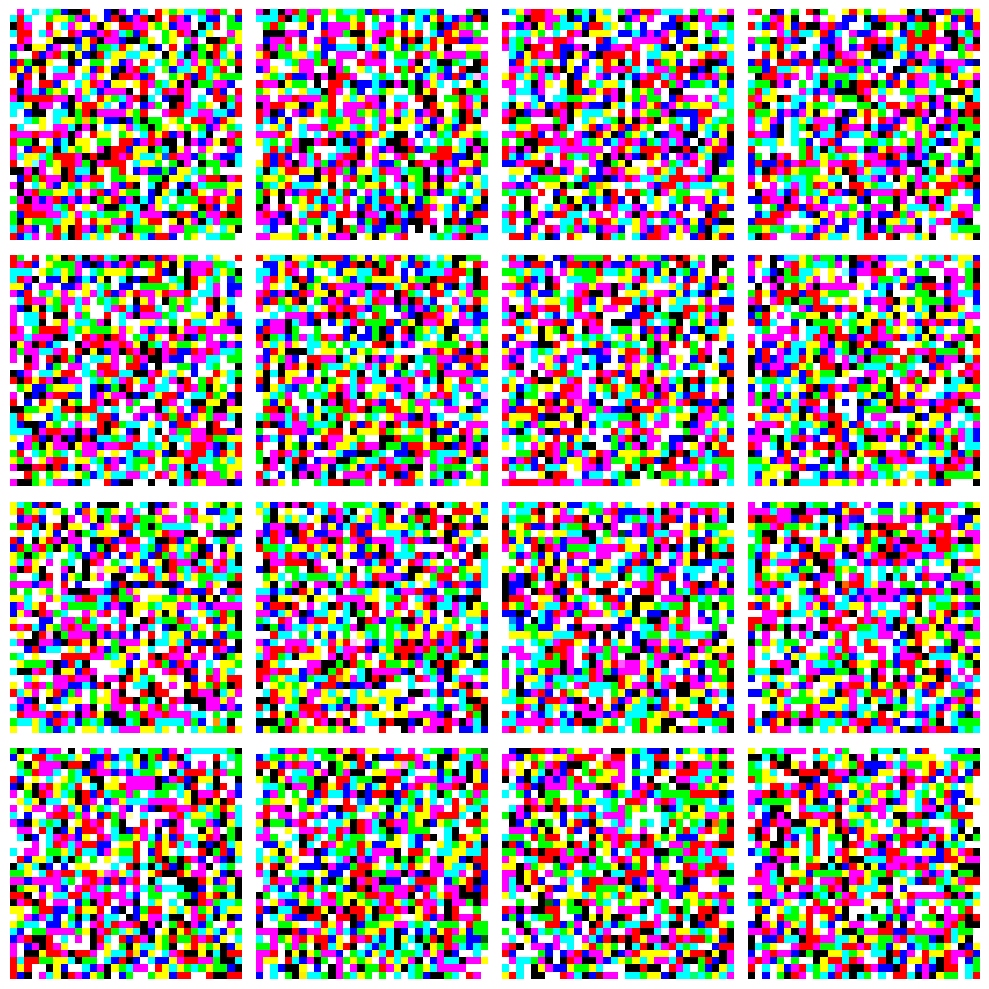

TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'PIL.Image.Image'>

In [45]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_samples(model, image_size=32, n_samples=16, device="cuda"):
    """Generate and visualize samples without FID"""
    model.eval()
    samples = sample(model, image_size, n_samples, device)
    samples = (samples.clamp(-1, 1) + 1) / 2  # Convert to [0, 1]
    
    plt.figure(figsize=(10, 10))
    for i in range(n_samples):
        plt.subplot(4, 4, i+1)
        plt.imshow(samples[i].permute(1, 2, 0).cpu().numpy())
        plt.axis('off')
    plt.tight_layout()
    plt.savefig("ddpm_samples.png")
    plt.show()
    return samples

def calculate_metrics(real_dataloader, generated_samples):
    """Calculate basic statistics for comparison"""
    real_pixels = torch.cat([batch for batch in real_dataloader]).float()
    fake_pixels = generated_samples.float()
    
    # Mean Absolute Error
    mae = torch.abs(real_pixels.mean() - fake_pixels.mean()).item()
    
    # Standard Deviation Comparison
    real_std = real_pixels.std()
    fake_std = fake_pixels.std()
    std_diff = torch.abs(real_std - fake_std).item()
    
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"Real Data STD: {real_std:.4f}")
    print(f"Generated Data STD: {fake_std:.4f}")
    print(f"STD Difference: {std_diff:.4f}")

# Usage example
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Load model
    model = UNet().to(device)
    model.load_state_dict(torch.load("C:\\Users\\Admin\\Downloads\\ddpm_model.pth"))
    test_dataset = YelpDataset('C:\\Users\\Admin\\Downloads\\test 1\\test\\original_photos\\')
    test_dataloader = DataLoader(test_dataset, batch_size=64)
    # Generate and visualize samples
    generated_samples = visualize_samples(model, image_size=32)
    
    # Calculate basic metrics
    calculate_metrics(test_dataloader, generated_samples)

In [53]:
pip install torchmetrics[image] Torch-fidelity

Note: you may need to restart the kernel to use updated packages.


In [55]:
# Main evaluation function
def evaluate_model(model, test_dataloader, image_size=32, device="cuda"):
    """Run full evaluation: save samples + calculate FID"""
    # Save visual samples
    save_samples(model, image_size, "ddpm_samples.png", device=device)
    
    # Calculate FID (use smaller sample size for quick test)
    fid_score = calculate_fid(test_dataloader, model, image_size, 
                            num_samples=min(1000, len(test_dataloader.dataset)), 
                            device=device)
    print(f"\nFID Score: {fid_score:.2f}")
    
    return fid_score